In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, torch, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (DataLoader, ConcatDataset,
                               Subset, Dataset)
from torchvision import transforms, datasets, models
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix,
                              classification_report)
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Imports done! Device: {device}")
print(f"🔥 GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU!'}")

Mounted at /content/drive
✅ Imports done! Device: cuda
🔥 GPU: Tesla T4


In [ ]:
BASE_PATH       = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models/cnn_model")
GRAPHS_PATH     = os.path.join(BASE_PATH, "outputs/graphs")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(GRAPHS_PATH,     exist_ok=True)

print("✅ Paths set!")
print(f"   Model save: {MODEL_SAVE_PATH}")

✅ Paths set!
   Model save: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model


In [ ]:
# Upload kaggle.json
from google.colab import files
print("📂 Upload kaggle.json...")
uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json',
          '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("✅ Kaggle configured!")

# Download deepfake images (60K face deepfakes)
os.makedirs('/content/deepfake_data', exist_ok=True)
print("\n⏳ Downloading deepfake image dataset (~1.7 GB)...")
!kaggle datasets download \
    -d manjilkarki/deepfake-and-real-images \
    -p /content/deepfake_data/
print("✅ Download complete!")

print("\n⏳ Unzipping...")
!unzip -q /content/deepfake_data/*.zip \
    -d /content/deepfake_data/
print("✅ Done!")

📂 Upload kaggle.json...


Saving kaggle.json to kaggle.json
✅ Kaggle configured!

⏳ Downloading deepfake image dataset (~1.7 GB)...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [00:17<00:00, 102MB/s]

✅ Download complete!

⏳ Unzipping...
✅ Done!


In [ ]:
os.makedirs('/content/cifake_data', exist_ok=True)
print("⏳ Downloading CIFAKE dataset (~105 MB)...")
!kaggle datasets download \
    -d birdy654/cifake-real-and-ai-generated-synthetic-images \
    -p /content/cifake_data/
print("✅ Download complete!")

print("\n⏳ Unzipping...")
!unzip -q /content/cifake_data/*.zip \
    -d /content/cifake_data/
print("✅ Done!")

⏳ Downloading CIFAKE dataset (~105 MB)...
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 142MB/s] 

✅ Download complete!

⏳ Unzipping...
✅ Done!


In [ ]:
# Deepfake dataset paths
DEEPFAKE_TRAIN = "/content/deepfake_data/Dataset/Train"
DEEPFAKE_VAL   = "/content/deepfake_data/Dataset/Validation"
DEEPFAKE_TEST  = "/content/deepfake_data/Dataset/Test"

# CIFAKE dataset paths
CIFAKE_TRAIN   = "/content/cifake_data/train"
CIFAKE_TEST    = "/content/cifake_data/test"

print("📊 Dataset verification:")
print(f"\n   Face Deepfake dataset:")
print(f"   Train Real : {len(os.listdir(DEEPFAKE_TRAIN+'/Real')):,}")
print(f"   Train Fake : {len(os.listdir(DEEPFAKE_TRAIN+'/Fake')):,}")

print(f"\n   CIFAKE dataset:")
print(f"   Train Real : {len(os.listdir(CIFAKE_TRAIN+'/REAL')):,}")
print(f"   Train Fake : {len(os.listdir(CIFAKE_TRAIN+'/FAKE')):,}")
print(f"   Test  Real : {len(os.listdir(CIFAKE_TEST+'/REAL')):,}")
print(f"   Test  Fake : {len(os.listdir(CIFAKE_TEST+'/FAKE')):,}")

total_train = (len(os.listdir(DEEPFAKE_TRAIN+'/Real')) +
               len(os.listdir(DEEPFAKE_TRAIN+'/Fake')) +
               len(os.listdir(CIFAKE_TRAIN+'/REAL'))  +
               len(os.listdir(CIFAKE_TRAIN+'/FAKE')))

print(f"\n   ✅ Combined training images: {total_train:,}")
print(f"   ⏱️  Est. training time: ~2-3 hrs on T4 GPU")

📊 Dataset verification:

   Face Deepfake dataset:
   Train Real : 70,001
   Train Fake : 70,001

   CIFAKE dataset:
   Train Real : 50,000
   Train Fake : 50,000
   Test  Real : 10,000
   Test  Fake : 10,000

   ✅ Combined training images: 240,002
   ⏱️  Est. training time: ~2-3 hrs on T4 GPU


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms, datasets, models
from sklearn.model_selection import train_test_split
from PIL import Image
import torch.nn as nn
import torch.optim as optim

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# ── Transforms ───────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── Load both datasets using ImageFolder ─────────────────────
# ImageFolder expects: root/FAKE/ and root/REAL/ structure
# CIFAKE already has this structure ✅
# Deepfake dataset has Train/Fake and Train/Real ✅

deepfake_train = datasets.ImageFolder(
    "/content/deepfake_data/Dataset/Train",
    transform=train_transforms)

cifake_train = datasets.ImageFolder(
    "/content/cifake_data/train",
    transform=train_transforms)

cifake_test = datasets.ImageFolder(
    "/content/cifake_data/test",
    transform=val_transforms)

# ── Check class mappings ─────────────────────────────────────
print(f"Deepfake class mapping : {deepfake_train.class_to_idx}")
print(f"CIFAKE class mapping   : {cifake_train.class_to_idx}")

# IMPORTANT: Both must have same label convention
# Fake=0, Real=1
# ImageFolder assigns labels alphabetically:
# FAKE → 0, REAL → 1 ✅ (F before R)
# Fake → 0, Real → 1 ✅ (F before R)
# Both are consistent!

print(f"\n✅ Class mappings consistent!")
print(f"   Label 0 = FAKE (face deepfake OR AI generated)")
print(f"   Label 1 = REAL (genuine photograph)")

Deepfake class mapping : {'Fake': 0, 'Real': 1}
CIFAKE class mapping   : {'FAKE': 0, 'REAL': 1}

✅ Class mappings consistent!
   Label 0 = FAKE (face deepfake OR AI generated)
   Label 1 = REAL (genuine photograph)


In [ ]:
from torch.utils.data import ConcatDataset, Subset
import random

# ── Combine train datasets ───────────────────────────────────
combined_train = ConcatDataset([deepfake_train, cifake_train])

# ── Use CIFAKE test as validation + test ─────────────────────
# Split CIFAKE test: 50% val, 50% test
cifake_test_indices = list(range(len(cifake_test)))
random.shuffle(cifake_test_indices)
mid = len(cifake_test_indices) // 2

val_dataset  = Subset(cifake_test,
                       cifake_test_indices[:mid])
test_dataset = Subset(cifake_test,
                       cifake_test_indices[mid:])

# ── DataLoaders ──────────────────────────────────────────────
train_loader = DataLoader(combined_train,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=NUM_WORKERS,
                          pin_memory=True)

val_loader   = DataLoader(val_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS,
                          pin_memory=True)

test_loader  = DataLoader(test_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f"✅ Combined DataLoaders ready!")
print(f"\n   Training images  : {len(combined_train):,}")
print(f"   Deepfake images  : {len(deepfake_train):,}")
print(f"   CIFAKE images    : {len(cifake_train):,}")
print(f"   Val images       : {len(val_dataset):,}")
print(f"   Test images      : {len(test_dataset):,}")
print(f"\n   Train batches    : {len(train_loader):,}")
print(f"   Val batches      : {len(val_loader):,}")
print(f"   ⏱️  Est. training time: ~2-3 hrs on T4 GPU")

✅ Combined DataLoaders ready!

   Training images  : 240,002
   Deepfake images  : 140,002
   CIFAKE images    : 100,000
   Val images       : 10,000
   Test images      : 10,000

   Train batches    : 7,501
   Val batches      : 313
   ⏱️  Est. training time: ~2-3 hrs on T4 GPU


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters():
        param.requires_grad = False
    for param in m.features[6:].parameters():
        param.requires_grad = True
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout/2),
        nn.Linear(512, num_classes)
    )
    return m

# ── Fresh model — NOT loading old weights ────────────────────
# Training from scratch on combined dataset
model_combined = build_efficientnet(num_classes=2, dropout=0.3)
model_combined = model_combined.to(device)

total     = sum(p.numel() for p in model_combined.parameters())
trainable = sum(p.numel() for p in model_combined.parameters()
                if p.requires_grad)

print(f"✅ Fresh EfficientNetB0 built!")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")
print(f"   Device          : {device}")
print(f"\n💡 Training on:")
print(f"   Face deepfakes  (GAN-based, FaceSwap)")
print(f"   AI generated    (Stable Diffusion)")
print(f"   Real photos     (genuine images)")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


✅ Fresh EfficientNetB0 built!
   Total params    : 4,664,446
   Trainable params: 3,812,638
   Device          : cuda

💡 Training on:
   Face deepfakes  (GAN-based, FaceSwap)
   AI generated    (Stable Diffusion)
   Real photos     (genuine images)


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

EPOCHS        = 10
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad,
           model_combined.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2)

BASE_PATH       = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models/cnn_model")
GRAPHS_PATH     = os.path.join(BASE_PATH, "outputs/graphs")

print(f"✅ Training setup ready!")
print(f"   Epochs        : {EPOCHS}")
print(f"   Learning rate : {LEARNING_RATE}")
print(f"   Optimizer     : AdamW")
print(f"   Scheduler     : ReduceLROnPlateau")
print(f"\n⏱️  Each epoch ~15-20 min → Total ~2.5-3 hrs")
print(f"   Paste anti-disconnect JS in browser console!")

✅ Training setup ready!
   Epochs        : 10
   Learning rate : 0.0001
   Optimizer     : AdamW
   Scheduler     : ReduceLROnPlateau

⏱️  Each epoch ~15-20 min → Total ~2.5-3 hrs
   Paste anti-disconnect JS in browser console!


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds       = torch.argmax(outputs, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        if (batch_idx+1) % 500 == 0:
            print(f"   Step {batch_idx+1:>4}/{len(loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {correct/total*100:.2f}%")
    return total_loss/len(loader), correct/total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = torch.argmax(outputs, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels


# ── Run Training ─────────────────────────────────────────────
history      = {'train_loss':[], 'val_loss':[],
                'train_acc' :[], 'val_acc' :[]}
best_val_acc = 0
best_state   = None

print("🚀 Training Combined CNN (Face Deepfake + AI Generated)!")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model_combined, train_loader,
        criterion, optimizer, device)

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model_combined, val_loader, criterion, device)

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state   = {k: v.clone()
                        for k, v in model_combined.state_dict().items()}
        torch.save(best_state,
                   f"{MODEL_SAVE_PATH}/efficientnet_combined_best.pth")
        print(f"   💾 Best saved! Val Acc: {v_acc*100:.2f}%")

    torch.save({
        'epoch'          : epoch+1,
        'model_state'    : model_combined.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc'        : v_acc,
        'history'        : history
    }, f"{MODEL_SAVE_PATH}/combined_checkpoint_epoch_{epoch+1}.pth")

    print(f"\n   📊 Epoch {epoch+1} Summary")
    print(f"      Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"      Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    print(f"      Val F1: {f1_score(v_labels, v_preds)*100:.2f}%")

print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc*100:.2f}%")
model_combined.load_state_dict(best_state)
print("✅ Best weights restored!")

🚀 Training Combined CNN (Face Deepfake + AI Generated)!

📌 Epoch 1/10
---------------------------------------------


KeyboardInterrupt: 

In [ ]:
# ── Load checkpoint from epoch 6 ────────────────────────────
print("⏳ Loading epoch 6 checkpoint...")
checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/combined_checkpoint_epoch_6.pth",
    map_location=device)

model_combined.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])
history      = checkpoint['history']
best_val_acc = max(history['val_acc'])
start_epoch  = checkpoint['epoch']   # = 6

print(f"✅ Resumed from epoch {start_epoch}!")
print(f"   Best val acc so far : {best_val_acc*100:.2f}%")
print(f"   Val acc per epoch   : {[round(a*100,2) for a in history['val_acc']]}")

# ── Train epochs 7 → 10 ─────────────────────────────────────
EPOCHS = 10

print(f"\n🚀 Resuming Training from Epoch {start_epoch+1}...")
print("=" * 55)

for epoch in range(start_epoch, EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model_combined, train_loader,
        criterion, optimizer, device)

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model_combined, val_loader, criterion, device)

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state   = {k: v.clone()
                        for k, v in model_combined.state_dict().items()}
        torch.save(best_state,
                   f"{MODEL_SAVE_PATH}/efficientnet_combined_best.pth")
        print(f"   💾 Best saved! Val Acc: {v_acc*100:.2f}%")

    torch.save({
        'epoch'          : epoch+1,
        'model_state'    : model_combined.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc'        : v_acc,
        'history'        : history
    }, f"{MODEL_SAVE_PATH}/combined_checkpoint_epoch_{epoch+1}.pth")
    print(f"   💾 Checkpoint saved → epoch_{epoch+1}.pth")

    print(f"\n   📊 Epoch {epoch+1} Summary")
    print(f"      Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"      Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    print(f"      Val F1: {f1_score(v_labels, v_preds)*100:.2f}%")

print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc*100:.2f}%")
model_combined.load_state_dict(best_state)
print("✅ Best weights restored!")

⏳ Loading epoch 6 checkpoint...
✅ Resumed from epoch 6!
   Best val acc so far : 97.42%
   Val acc per epoch   : [95.67, 95.97, 96.95, 96.9, 97.42, 96.84]

🚀 Resuming Training from Epoch 7...

📌 Epoch 7/10
---------------------------------------------
   Step  500/7501 | Loss: 0.0013 | Acc: 98.25%
   Step 1000/7501 | Loss: 0.0071 | Acc: 98.19%
   Step 1500/7501 | Loss: 0.0439 | Acc: 98.18%
   Step 2000/7501 | Loss: 0.0348 | Acc: 98.21%
   Step 2500/7501 | Loss: 0.0017 | Acc: 98.21%
   Step 3000/7501 | Loss: 0.0493 | Acc: 98.17%
   Step 3500/7501 | Loss: 0.0963 | Acc: 98.15%
   Step 4000/7501 | Loss: 0.0282 | Acc: 98.16%
   Step 4500/7501 | Loss: 0.1474 | Acc: 98.17%
   Step 5000/7501 | Loss: 0.0129 | Acc: 98.16%
   Step 5500/7501 | Loss: 0.1190 | Acc: 98.16%
   Step 6000/7501 | Loss: 0.0294 | Acc: 98.17%
   Step 6500/7501 | Loss: 0.0115 | Acc: 98.17%
   Step 7000/7501 | Loss: 0.0061 | Acc: 98.17%
   Step 7500/7501 | Loss: 0.0174 | Acc: 98.16%
   💾 Best saved! Val Acc: 97.66%
   💾 Check

KeyboardInterrupt: 

In [ ]:
# ── Load checkpoint from epoch 8 ────────────────────────────
print("⏳ Loading epoch 8 checkpoint...")

checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/combined_checkpoint_epoch_8.pth",
    map_location=device
)

model_combined.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

history = checkpoint['history']
best_val_acc = max(history['val_acc'])
start_epoch = checkpoint['epoch']  # = 8

print(f"✅ Resumed from epoch {start_epoch}!")
print(f"   Best val acc so far : {best_val_acc*100:.2f}%")
print(f"   Val acc per epoch   : {[round(a*100, 2) for a in history['val_acc']]}")

# Keep a copy of the current best weights
best_state = {
    k: v.clone()
    for k, v in model_combined.state_dict().items()
}

# ── Train epochs 9 → 10 ─────────────────────────────────────
EPOCHS = 10

print(f"\n🚀 Resuming Training from Epoch {start_epoch + 1}...")
print("=" * 55)

for epoch in range(start_epoch, EPOCHS):

    print(f"\n📌 Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 45)

    # Training
    t_loss, t_acc = train_epoch(
        model_combined,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model_combined,
        val_loader,
        criterion,
        device
    )

    scheduler.step(v_loss)

    # Save history
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Save best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc

        best_state = {
            k: v.clone()
            for k, v in model_combined.state_dict().items()
        }

        torch.save(
            best_state,
            f"{MODEL_SAVE_PATH}/efficientnet_combined_best.pth"
        )

        print(f"   💾 Best saved! Val Acc: {v_acc*100:.2f}%")

    # Save checkpoint
    torch.save({
        'epoch': epoch + 1,
        'model_state': model_combined.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc': v_acc,
        'history': history
    },
    f"{MODEL_SAVE_PATH}/combined_checkpoint_epoch_{epoch + 1}.pth")

    print(f"   💾 Checkpoint saved → epoch_{epoch + 1}.pth")

    # Epoch summary
    print(f"\n   📊 Epoch {epoch + 1} Summary")
    print(f"      Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"      Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    print(f"      Val F1: {f1_score(v_labels, v_preds)*100:.2f}%")

print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc*100:.2f}%")

# Restore best weights
model_combined.load_state_dict(best_state)

print("✅ Best weights restored!")

⏳ Loading epoch 8 checkpoint...
✅ Resumed from epoch 8!
   Best val acc so far : 97.66%
   Val acc per epoch   : [95.67, 95.97, 96.95, 96.9, 97.42, 96.84, 97.66, 97.08]

🚀 Resuming Training from Epoch 9...

📌 Epoch 9/10
---------------------------------------------
   Step  500/7501 | Loss: 0.0073 | Acc: 98.51%
   Step 1000/7501 | Loss: 0.0919 | Acc: 98.49%
   Step 1500/7501 | Loss: 0.0443 | Acc: 98.44%
   Step 2000/7501 | Loss: 0.0095 | Acc: 98.47%
   Step 2500/7501 | Loss: 0.0256 | Acc: 98.45%
   Step 3000/7501 | Loss: 0.0140 | Acc: 98.45%
   Step 3500/7501 | Loss: 0.0026 | Acc: 98.45%
   Step 4000/7501 | Loss: 0.0037 | Acc: 98.43%
   Step 4500/7501 | Loss: 0.0008 | Acc: 98.43%
   Step 5000/7501 | Loss: 0.0094 | Acc: 98.44%
   Step 5500/7501 | Loss: 0.0716 | Acc: 98.44%
   Step 6000/7501 | Loss: 0.0384 | Acc: 98.43%
   Step 6500/7501 | Loss: 0.2275 | Acc: 98.43%
   Step 7000/7501 | Loss: 0.0389 | Acc: 98.41%
   Step 7500/7501 | Loss: 0.0308 | Acc: 98.42%
   💾 Best saved! Val Acc: 97.

🔍 Evaluating on CIFAKE test set...

  📊 COMBINED CNN — FINAL TEST RESULTS
  Accuracy  : 97.72%
  Precision : 98.40%
  Recall    : 96.97%
  F1-Score  : 97.68%
              precision    recall  f1-score   support

        Fake       0.97      0.98      0.98      5043
        Real       0.98      0.97      0.98      4957

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



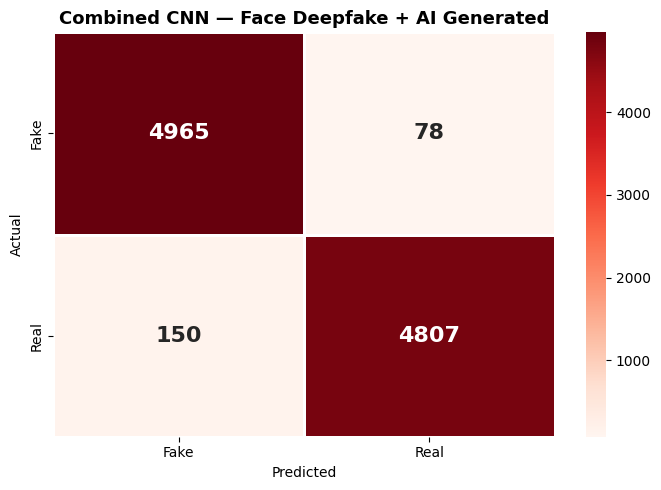

✅ Combined model saved to Drive!


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Evaluating on CIFAKE test set...")
_, test_acc, test_preds, test_labels = eval_epoch(
    model_combined, test_loader, criterion, device)

acc  = accuracy_score(test_labels,  test_preds)
prec = precision_score(test_labels, test_preds, zero_division=0)
rec  = recall_score(test_labels,    test_preds, zero_division=0)
f1   = f1_score(test_labels,        test_preds, zero_division=0)

print(f"\n{'='*50}")
print(f"  📊 COMBINED CNN — FINAL TEST RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"{'='*50}")
print(classification_report(test_labels, test_preds,
                             target_names=['Fake','Real'],
                             zero_division=0))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'],
            linewidths=2, linecolor='white',
            annot_kws={"size":16,"weight":"bold"})
plt.title('Combined CNN — Face Deepfake + AI Generated',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{GRAPHS_PATH}/combined_cnn_confusion.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Save final model
torch.save(model_combined.state_dict(),
           f"{MODEL_SAVE_PATH}/efficientnet_combined_final.pth")
print("✅ Combined model saved to Drive!")

In [ ]:
# Fine-tune video model on CIFAKE as well
# So it detects AI generated video frames

print("🔄 Fine-tuning video model on CIFAKE...")
print("   Loading existing video model...")

cnn_video_model = build_efficientnet()
weights = torch.load(
    f"{MODEL_SAVE_PATH}/efficientnet_video_finetuned.pth",
    map_location=device)
cnn_video_model.load_state_dict(
    weights['model_state'] if 'model_state' in weights
    else weights)
cnn_video_model = cnn_video_model.to(device)

# Unfreeze more layers for adaptation
for param in cnn_video_model.features[4:].parameters():
    param.requires_grad = True
for param in cnn_video_model.classifier.parameters():
    param.requires_grad = True

optimizer_v = optim.AdamW(
    filter(lambda p: p.requires_grad,
           cnn_video_model.parameters()),
    lr=3e-5,           # very low LR — preserve video knowledge
    weight_decay=1e-4
)

print("🚀 Fine-tuning video model on CIFAKE (3 epochs)...")
print("=" * 55)

for epoch in range(3):
    print(f"\n📌 Epoch {epoch+1}/3")
    t_loss, t_acc = train_epoch(
        cnn_video_model, train_loader,
        criterion, optimizer_v, device)
    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        cnn_video_model, val_loader, criterion, device)

    print(f"   Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"   Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")

torch.save(
    cnn_video_model.state_dict(),
    f"{MODEL_SAVE_PATH}/efficientnet_video_ai_updated.pth")
print("\n✅ Updated video model saved!")
print("   Now detects: face deepfakes + AI generated videos")

🔄 Fine-tuning video model on CIFAKE...
   Loading existing video model...
🚀 Fine-tuning video model on CIFAKE (3 epochs)...

📌 Epoch 1/3
   Step  500/7501 | Loss: 0.2542 | Acc: 89.21%
   Step 1000/7501 | Loss: 0.1091 | Acc: 91.72%
   Step 1500/7501 | Loss: 0.0139 | Acc: 92.87%
   Step 2000/7501 | Loss: 0.1044 | Acc: 93.51%
   Step 2500/7501 | Loss: 0.0123 | Acc: 94.01%
   Step 3000/7501 | Loss: 0.0261 | Acc: 94.38%
   Step 3500/7501 | Loss: 0.0039 | Acc: 94.63%
   Step 4000/7501 | Loss: 0.2338 | Acc: 94.85%
   Step 4500/7501 | Loss: 0.0891 | Acc: 95.03%
   Step 5000/7501 | Loss: 0.1641 | Acc: 95.18%
   Step 5500/7501 | Loss: 0.0821 | Acc: 95.32%
   Step 6000/7501 | Loss: 0.0898 | Acc: 95.44%
   Step 6500/7501 | Loss: 0.1470 | Acc: 95.56%
   Step 7000/7501 | Loss: 0.0719 | Acc: 95.66%
   Step 7500/7501 | Loss: 0.0688 | Acc: 95.76%
   Train → Loss: 0.1110 | Acc: 95.76%
   Val   → Loss: 0.0982 | Acc: 96.38%

📌 Epoch 2/3
   Step  500/7501 | Loss: 0.0106 | Acc: 97.37%
   Step 1000/7501 | Lo

RETRAINING WITH DIFFERENT DATASETS FOR face-swap + AI faces + general AI generation

In [ ]:
# ── Check what's available ───────────────────────────────────
import os, torch
from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BASE_PATH       = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models/cnn_model")

# Check original model exists
orig = os.path.join(MODEL_SAVE_PATH, "efficientnet_best.pth")
print(f"Original model: {'✅ EXISTS' if os.path.exists(orig) else '❌ MISSING'}")

# Check combined model
comb = os.path.join(MODEL_SAVE_PATH, "efficientnet_combined_best.pth")
print(f"Combined model: {'✅ EXISTS' if os.path.exists(comb) else '❌ MISSING'}")

Mounted at /content/drive
Device: cuda
Original model: ✅ EXISTS
Combined model: ✅ EXISTS


In [ ]:
from google.colab import files
print("📂 Upload kaggle.json...")
uploaded = files.upload()
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("✅ Kaggle ready!")

# Dataset 1: Original 60K deepfakes (face swaps)
os.makedirs('/content/deepfake_data', exist_ok=True)
print("\n⏳ Downloading Deepfake 60K...")
!kaggle datasets download \
    -d manjilkarki/deepfake-and-real-images \
    -p /content/deepfake_data/
!unzip -q /content/deepfake_data/*.zip \
    -d /content/deepfake_data/
print("✅ Deepfake 60K ready!")

# Dataset 2: 140K Real and Fake Faces (StyleGAN AI generated)
os.makedirs('/content/faces_data', exist_ok=True)
print("\n⏳ Downloading 140K Real and Fake Faces...")
!kaggle datasets download \
    -d xhlulu/140k-real-and-fake-faces \
    -p /content/faces_data/
!unzip -q /content/faces_data/*.zip \
    -d /content/faces_data/
print("✅ 140K Faces ready!")

📂 Upload kaggle.json...


Saving kaggle.json to kaggle.json
✅ Kaggle ready!

⏳ Downloading Deepfake 60K...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [00:13<00:00, 137MB/s]

✅ Deepfake 60K ready!

⏳ Downloading 140K Real and Fake Faces...
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:49<00:00, 82.1MB/s]

✅ 140K Faces ready!


In [ ]:
print("📁 Deepfake 60K structure:")
for root, dirs, files_list in os.walk('/content/deepfake_data/Dataset/'):
    level = root.replace('/content/deepfake_data/Dataset/', '').count(os.sep)
    if level <= 1:
        imgs = [f for f in files_list if f.lower().endswith(('.jpg','.png','.jpeg'))]
        if imgs: print(f"  {root.split('/')[-1]}: {len(imgs):,} images")

print("\n📁 140K Faces structure:")
for root, dirs, files_list in os.walk('/content/faces_data/'):
    level = root.replace('/content/faces_data/', '').count(os.sep)
    if level <= 2:
        imgs = [f for f in files_list if f.lower().endswith(('.jpg','.png','.jpeg'))]
        if imgs: print(f"  {root.split('/')[-1]}: {len(imgs):,} images")

📁 Deepfake 60K structure:
  Fake: 19,641 images
  Real: 19,787 images
  Fake: 70,001 images
  Real: 70,001 images
  Fake: 5,492 images
  Real: 5,413 images

📁 140K Faces structure:


In [ ]:
# Check 140K faces more carefully
import os

print("📁 Full 140K faces folder tree:")
for root, dirs, files_list in os.walk('/content/faces_data/'):
    level = root.replace('/content/faces_data/', '').count(os.sep)
    if level <= 3:
        indent = '  ' * level
        imgs = [f for f in files_list
                if f.lower().endswith(('.jpg','.png','.jpeg'))]
        print(f"{indent}📂 {os.path.basename(root)}/")
        if imgs:
            print(f"{'  '*(level+1)}🖼️  {len(imgs):,} images")
        elif files_list:
            print(f"{'  '*(level+1)}📄 {len(files_list)} files: {files_list[:3]}")

📁 Full 140K faces folder tree:
📂 /
  📄 4 files: ['valid.csv', 'test.csv', 'train.csv']
📂 real_vs_fake/
  📂 real-vs-fake/
    📂 valid/
      📂 fake/
        🖼️  10,000 images
      📂 real/
        🖼️  10,000 images
    📂 train/
      📂 fake/
        🖼️  50,000 images
      📂 real/
        🖼️  50,000 images
    📂 test/
      📂 fake/
        🖼️  10,000 images
      📂 real/
        🖼️  10,000 images


In [ ]:
import os

# Remove the tiny useless dataset
!rm -rf /content/ai_real_data/
os.makedirs('/content/ai_real_data', exist_ok=True)

# Download the good one
print("⏳ Downloading AI vs Real 30K dataset...")
!kaggle datasets download \
    -d tristanzhang32/ai-generated-images-vs-real-images \
    -p /content/ai_real_data/
!unzip -q /content/ai_real_data/*.zip \
    -d /content/ai_real_data/
print("✅ Done!")

# Check structure
print("\n📁 AI vs Real 30K structure:")
for root, dirs, files_list in os.walk('/content/ai_real_data/'):
    level = root.replace('/content/ai_real_data/', '').count(os.sep)
    if level <= 3:
        imgs = [f for f in files_list
                if f.lower().endswith(('.jpg','.png','.jpeg','.webp'))]
        if imgs:
            indent = '  ' * level
            print(f"{indent}📂 {os.path.basename(root)}/  →  {len(imgs):,} images")

# Confirm all 3 datasets
print("\n📊 All datasetns summary:")
paths = [
    ("/content/deepfake_data/Dataset/Train/Fake", "Deepfake Train Fake"),
    ("/content/deepfake_data/Dataset/Train/Real", "Deepfake Train Real"),
    ("/content/faces_data/real_vs_fake/real-vs-fake/train/fake", "140K Faces Train Fake"),
    ("/content/faces_data/real_vs_fake/real-vs-fake/train/real", "140K Faces Train Real"),
]

for path, name in paths:
    if os.path.exists(path):
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg','.png','.jpeg'))])
        print(f"   ✅ {name}: {count:,} images")
    else:
        print(f"   ❌ {name}: NOT FOUND at {path}")

⏳ Downloading AI vs Real 30K dataset...
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
License(s): MIT
100% 48.4G/48.4G [10:43<00:00, 80.9MB/s]

/content/ai_real_data/test/real/1916.jpg:  write error (disk full?).  Continue? (y/n/^C) ✅ Done!

📁 AI vs Real 30K structure:
  📂 fake/  →  6,000 images
  📂 real/  →  1,916 images

📊 All datasets summary:
   ✅ Deepfake Train Fake: 70,001 images
   ✅ Deepfake Train Real: 70,001 images
   ✅ 140K Faces Train Fake: 50,000 images
   ✅ 140K Faces Train Real: 50,000 images


In [ ]:
import os

print("🧹 Emergency cleanup...")

# Remove the 48GB dataset immediately
!rm -rf /content/ai_real_data/
print("✅ 48GB AI dataset removed!")

# Remove all zip files
!find /content -name "*.zip" -delete
print("✅ ZIP files removed!")

# Remove validation and test folders (not needed for training)
!rm -rf /content/deepfake_data/Dataset/Validation/
!rm -rf /content/deepfake_data/Dataset/Test/
print("✅ Validation/Test folders removed!")

# Remove CIFAKE if still there
!rm -rf /content/cifake_data/
print("✅ CIFAKE removed!")

# Check disk now
print("\n💾 Disk space now:")
!df -h /content

print("\n📁 What remains:")
!du -sh /content/deepfake_data/ 2>/dev/null
!du -sh /content/faces_data/ 2>/dev/null

🧹 Emergency cleanup...
✅ 48GB AI dataset removed!
✅ ZIP files removed!
✅ Validation/Test folders removed!
✅ CIFAKE removed!

💾 Disk space now:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   53G   61G  47% /

📁 What remains:
1.5G	/content/deepfake_data/
4.1G	/content/faces_data/


In [ ]:
import os, torch, random, warnings
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import transforms, datasets, models
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
print(f"🔥 GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU!'}")

BASE_PATH       = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models/cnn_model")
GRAPHS_PATH     = os.path.join(BASE_PATH, "outputs/graphs")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

✅ Device: cuda
🔥 GPU: Tesla T4


In [ ]:
# ── Dataset paths ────────────────────────────────────────────
# Dataset 1: Deepfake 60K (face swaps)
D1_FAKE = "/content/deepfake_data/Dataset/Train/Fake"
D1_REAL = "/content/deepfake_data/Dataset/Train/Real"

# Dataset 2: 140K Real/Fake Faces (StyleGAN AI faces)
D2_FAKE = "/content/faces_data/real_vs_fake/real-vs-fake/train/fake"
D2_REAL = "/content/faces_data/real_vs_fake/real-vs-fake/train/real"

# Val + Test from 140K faces
D2_VAL_FAKE  = "/content/faces_data/real_vs_fake/real-vs-fake/valid/fake"
D2_VAL_REAL  = "/content/faces_data/real_vs_fake/real-vs-fake/valid/real"
D2_TEST_FAKE = "/content/faces_data/real_vs_fake/real-vs-fake/test/fake"
D2_TEST_REAL = "/content/faces_data/real_vs_fake/real-vs-fake/test/real"

print("📊 Dataset verification:")
for name, path in [
    ("D1 Train Fake (face swap)", D1_FAKE),
    ("D1 Train Real (face swap)", D1_REAL),
    ("D2 Train Fake (StyleGAN)",  D2_FAKE),
    ("D2 Train Real (StyleGAN)",  D2_REAL),
    ("D2 Val   Fake",             D2_VAL_FAKE),
    ("D2 Val   Real",             D2_VAL_REAL),
    ("D2 Test  Fake",             D2_TEST_FAKE),
    ("D2 Test  Real",             D2_TEST_REAL),
]:
    if os.path.exists(path):
        n = len([f for f in os.listdir(path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"   ✅ {name:<30}: {n:,}")
    else:
        print(f"   ❌ {name:<30}: NOT FOUND")

📊 Dataset verification:
   ✅ D1 Train Fake (face swap)     : 70,001
   ✅ D1 Train Real (face swap)     : 70,001
   ✅ D2 Train Fake (StyleGAN)      : 50,000
   ✅ D2 Train Real (StyleGAN)      : 50,000
   ✅ D2 Val   Fake                 : 10,000
   ✅ D2 Val   Real                 : 10,000
   ✅ D2 Test  Fake                 : 10,000
   ✅ D2 Test  Real                 : 10,000


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

class FolderDataset(Dataset):
    """
    Loads images from two folders: fake_dir and real_dir.
    Label: 0 = Fake, 1 = Real
    """
    def __init__(self, fake_dir, real_dir, transform, max_per_class=None):
        self.transform = transform
        self.samples   = []

        # Load fake images
        fake_imgs = [os.path.join(fake_dir, f)
                     for f in os.listdir(fake_dir)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
        # Load real images
        real_imgs = [os.path.join(real_dir, f)
                     for f in os.listdir(real_dir)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]

        # Balance classes
        if max_per_class:
            fake_imgs = random.sample(fake_imgs,
                                      min(max_per_class, len(fake_imgs)))
            real_imgs = random.sample(real_imgs,
                                      min(max_per_class, len(real_imgs)))

        self.samples += [(p, 0) for p in fake_imgs]
        self.samples += [(p, 1) for p in real_imgs]
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            from PIL import Image
            img = Image.open(path).convert('RGB')
            return self.transform(img), torch.tensor(label, dtype=torch.long)
        except:
            # Skip corrupt images — return next item
            return self.__getitem__((idx+1) % len(self.samples))

print("✅ FolderDataset class ready!")

✅ FolderDataset class ready!


In [ ]:
# Use 50K per class from each dataset for balance
# Total: 100K fake + 100K real = 200K training images
MAX_PER_CLASS = 50000

print("⏳ Building combined dataset...")

train_d1 = FolderDataset(D1_FAKE, D1_REAL, train_transforms,
                          max_per_class=MAX_PER_CLASS)
train_d2 = FolderDataset(D2_FAKE, D2_REAL, train_transforms,
                          max_per_class=MAX_PER_CLASS)

combined_train = ConcatDataset([train_d1, train_d2])

# Validation: use 140K faces val set
val_dataset  = FolderDataset(D2_VAL_FAKE,  D2_VAL_REAL,
                              val_transforms)
test_dataset = FolderDataset(D2_TEST_FAKE, D2_TEST_REAL,
                              val_transforms)

train_loader = DataLoader(combined_train, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f"✅ DataLoaders ready!")
print(f"\n   D1 (face swap)    : {len(train_d1):,} images")
print(f"   D2 (StyleGAN)     : {len(train_d2):,} images")
print(f"   Combined train    : {len(combined_train):,} images")
print(f"   Validation        : {len(val_dataset):,} images")
print(f"   Test              : {len(test_dataset):,} images")
print(f"   Train batches     : {len(train_loader):,}")
print(f"\n⏱️  Est. training time: ~1.5-2 hrs per epoch on T4")

⏳ Building combined dataset...
✅ DataLoaders ready!

   D1 (face swap)    : 100,000 images
   D2 (StyleGAN)     : 100,000 images
   Combined train    : 200,000 images
   Validation        : 20,000 images
   Test              : 20,000 images
   Train batches     : 6,250

⏱️  Est. training time: ~1.5-2 hrs per epoch on T4


In [ ]:
def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters():
        param.requires_grad = False
    # Unfreeze last 4 blocks for fine-tuning
    for param in m.features[5:].parameters():
        param.requires_grad = True
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_f, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout/2),
        nn.Linear(512, num_classes)
    )
    return m

# Load original best model as starting point
ORIGINAL_MODEL = os.path.join(MODEL_SAVE_PATH, "efficientnet_best.pth")

print("⏳ Loading original best model as base...")
model = build_efficientnet(num_classes=2, dropout=0.3)
w = torch.load(ORIGINAL_MODEL, map_location=device)
model.load_state_dict(w['model_state'] if 'model_state' in w else w)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)

print(f"✅ Original model loaded!")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")
print(f"\n💡 Strategy: Fine-tune on face swaps + StyleGAN faces")
print(f"   Starting from already-trained weights → faster convergence")

⏳ Loading original best model as base...
✅ Original model loaded!
   Total params    : 4,664,446
   Trainable params: 4,355,786

💡 Strategy: Fine-tune on face swaps + StyleGAN faces
   Starting from already-trained weights → faster convergence


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import torch

BASE_PATH       = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models/cnn_model")
GRAPHS_PATH     = os.path.join(BASE_PATH, "outputs/graphs")
ORIGINAL_MODEL  = os.path.join(MODEL_SAVE_PATH, "efficientnet_best.pth")

# Check file exists and is readable
print(f"📁 Checking model file...")
if os.path.exists(ORIGINAL_MODEL):
    size = os.path.getsize(ORIGINAL_MODEL) / (1024**2)
    print(f"✅ Found: efficientnet_best.pth ({size:.1f} MB)")
else:
    print(f"❌ Not found at: {ORIGINAL_MODEL}")
    print(f"\n📁 Available models:")
    for f in os.listdir(MODEL_SAVE_PATH):
        size = os.path.getsize(
            os.path.join(MODEL_SAVE_PATH, f)) / (1024**2)
        print(f"   {f}  ({size:.1f} MB)")

Mounted at /content/drive
📁 Checking model file...
✅ Found: efficientnet_best.pth (18.1 MB)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("⏳ Loading original best model...")
model = build_efficientnet(num_classes=2, dropout=0.3)

w = torch.load(ORIGINAL_MODEL, map_location=device)
model.load_state_dict(w['model_state'] if 'model_state' in w else w)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)

print(f"✅ Original model loaded successfully!")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")
print(f"   Device          : {next(model.parameters()).device}")

Device: cuda
⏳ Loading original best model...
✅ Original model loaded successfully!
   Total params    : 4,664,446
   Trainable params: 4,355,786
   Device          : cuda:0


In [ ]:
EPOCHS        = 10
LEARNING_RATE = 5e-5   # Lower LR — preserve existing knowledge

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2)

print(f"✅ Training setup ready!")
print(f"   Epochs        : {EPOCHS}")
print(f"   Learning rate : {LEARNING_RATE} (low — preserve knowledge)")
print(f"   Optimizer     : AdamW")
print(f"   Scheduler     : ReduceLROnPlateau")
print(f"\n⏱️  Total est. time: ~3-4 hrs")
print(f"   Paste anti-disconnect JS in browser console!")

✅ Training setup ready!
   Epochs        : 10
   Learning rate : 5e-05 (low — preserve knowledge)
   Optimizer     : AdamW
   Scheduler     : ReduceLROnPlateau

⏱️  Total est. time: ~3-4 hrs
   Paste anti-disconnect JS in browser console!


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds       = torch.argmax(outputs, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        if (batch_idx+1) % 500 == 0:
            print(f"   Step {batch_idx+1:>4}/{len(loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {correct/total*100:.2f}%")
    return total_loss/len(loader), correct/total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = torch.argmax(outputs, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels

# ── Run Training ─────────────────────────────────────────────
history      = {'train_loss':[],'val_loss':[],
                'train_acc' :[],'val_acc' :[]}
best_val_acc = 0
best_state   = None

print("🚀 Starting Training — Face Swap + StyleGAN Combined!")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, device)
    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device)

    scheduler.step(v_loss)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state   = {k: v.clone()
                        for k, v in model.state_dict().items()}
        torch.save(best_state,
                   f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth")
        print(f"   💾 Best saved! Val Acc: {v_acc*100:.2f}%")

    torch.save({
        'epoch'          : epoch+1,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc'        : v_acc,
        'history'        : history
    }, f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_{epoch+1}.pth")
    print(f"   💾 Checkpoint saved!")

    print(f"\n   📊 Epoch {epoch+1} Summary")
    print(f"      Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"      Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    print(f"      Val F1: {f1_score(v_labels, v_preds)*100:.2f}%")

print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc*100:.2f}%")
model.load_state_dict(best_state)
print("✅ Best weights restored!")

🚀 Starting Training — Face Swap + StyleGAN Combined!

📌 Epoch 1/10
---------------------------------------------
   Step  500/6250 | Loss: 0.3750 | Acc: 84.34%
   Step 1000/6250 | Loss: 0.1730 | Acc: 87.43%
   Step 1500/6250 | Loss: 0.1529 | Acc: 89.19%
   Step 2000/6250 | Loss: 0.0681 | Acc: 90.30%
   Step 2500/6250 | Loss: 0.0835 | Acc: 91.08%
   Step 3000/6250 | Loss: 0.3406 | Acc: 91.77%
   Step 3500/6250 | Loss: 0.0743 | Acc: 92.36%
   Step 4000/6250 | Loss: 0.0683 | Acc: 92.76%
   Step 4500/6250 | Loss: 0.0784 | Acc: 93.13%
   Step 5000/6250 | Loss: 0.0520 | Acc: 93.44%
   Step 5500/6250 | Loss: 0.1320 | Acc: 93.70%
   Step 6000/6250 | Loss: 0.3615 | Acc: 93.93%
   💾 Best saved! Val Acc: 97.58%
   💾 Checkpoint saved!

   📊 Epoch 1 Summary
      Train → Loss: 0.1485 | Acc: 94.03%
      Val   → Loss: 0.0682 | Acc: 97.58%
      Val F1: 97.53%

📌 Epoch 2/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0943 | Acc: 96.76%
   Step 1000/6250 | Loss: 0.0276 | 

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
MODEL_SAVE_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model"

print("📁 V2 checkpoints saved:")
for f in sorted(os.listdir(MODEL_SAVE_PATH)):
    if 'v2' in f.lower():
        size = os.path.getsize(os.path.join(MODEL_SAVE_PATH,f))/1024**2
        print(f"   ✅ {f}  ({size:.1f} MB)")

Mounted at /content/drive
📁 V2 checkpoints saved:
   ✅ efficientnet_v2_best.pth  (18.1 MB)
   ✅ v2_checkpoint_epoch_1.pth  (51.4 MB)


In [ ]:
# Load checkpoint
checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_1.pth",
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

history = checkpoint['history']
start_epoch = checkpoint['epoch']  # = 1
best_val_acc = checkpoint['val_acc']

print(f"✅ Resuming from Epoch {start_epoch + 1}")

# Continue training
for epoch in range(start_epoch, EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device
    )

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state = {k: v.clone()
                      for k, v in model.state_dict().items()}

        torch.save(
            best_state,
            f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth"
        )

        print(f"💾 Best saved! Val Acc: {v_acc*100:.2f}%")

    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc': v_acc,
        'history': history
    }, f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_{epoch+1}.pth")

    print(f"💾 Checkpoint saved!")

✅ Resuming from Epoch 2

📌 Epoch 2/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0297 | Acc: 97.17%
   Step 1000/6250 | Loss: 0.1020 | Acc: 97.12%
   Step 1500/6250 | Loss: 0.0043 | Acc: 97.06%
   Step 2000/6250 | Loss: 0.0041 | Acc: 97.01%
   Step 2500/6250 | Loss: 0.0358 | Acc: 97.02%
   Step 3000/6250 | Loss: 0.2667 | Acc: 97.05%
   Step 3500/6250 | Loss: 0.0094 | Acc: 97.07%
   Step 4000/6250 | Loss: 0.0322 | Acc: 97.06%
   Step 4500/6250 | Loss: 0.0766 | Acc: 97.05%
   Step 5000/6250 | Loss: 0.0659 | Acc: 97.05%
   Step 5500/6250 | Loss: 0.0340 | Acc: 97.05%
   Step 6000/6250 | Loss: 0.1657 | Acc: 97.04%
💾 Best saved! Val Acc: 97.67%
💾 Checkpoint saved!

📌 Epoch 3/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0246 | Acc: 97.05%
   Step 1000/6250 | Loss: 0.0434 | Acc: 96.96%
   Step 1500/6250 | Loss: 0.0344 | Acc: 96.99%
   Step 2000/6250 | Loss: 0.0349 | Acc: 97.04%
   Step 2500/6250 | Loss: 0.1406 | Acc: 97.01%
   Step

KeyboardInterrupt: 

In [ ]:
# Load Epoch 3 checkpoint
checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_3.pth",
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

history = checkpoint['history']
best_val_acc = max(history['val_acc'])  # best validation accuracy so far
start_epoch = checkpoint['epoch']       # should be 3

print(f"✅ Resuming from Epoch {start_epoch + 1}")

for epoch in range(start_epoch, EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device
    )

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(
            model.state_dict(),
            f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth"
        )

    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc': v_acc,
        'history': history
    }, f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_{epoch+1}.pth")

    print(f"Train Acc: {t_acc*100:.2f}% | Val Acc: {v_acc*100:.2f}%")

print("🎉 Training completed!")

✅ Resuming from Epoch 4

📌 Epoch 4/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0978 | Acc: 96.89%
   Step 1000/6250 | Loss: 0.1820 | Acc: 97.00%
   Step 1500/6250 | Loss: 0.0099 | Acc: 97.08%
   Step 2000/6250 | Loss: 0.0581 | Acc: 97.05%
   Step 2500/6250 | Loss: 0.0771 | Acc: 97.11%
   Step 3000/6250 | Loss: 0.0060 | Acc: 97.12%
   Step 3500/6250 | Loss: 0.0442 | Acc: 97.12%
   Step 4000/6250 | Loss: 0.0087 | Acc: 97.10%
   Step 4500/6250 | Loss: 0.0281 | Acc: 97.08%
   Step 5000/6250 | Loss: 0.0062 | Acc: 97.07%
   Step 5500/6250 | Loss: 0.1907 | Acc: 97.06%
   Step 6000/6250 | Loss: 0.2043 | Acc: 97.05%
Train Acc: 97.04% | Val Acc: 97.92%

📌 Epoch 5/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0139 | Acc: 97.01%
   Step 1000/6250 | Loss: 0.0243 | Acc: 97.01%
   Step 1500/6250 | Loss: 0.0215 | Acc: 97.00%
   Step 2000/6250 | Loss: 0.1008 | Acc: 97.00%
   Step 2500/6250 | Loss: 0.0093 | Acc: 97.02%


KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_4.pth",
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

history = checkpoint['history']
best_val_acc = max(history['val_acc'])
start_epoch = checkpoint['epoch']  # 4

print(f"✅ Resuming from Epoch {start_epoch + 1}")

for epoch in range(start_epoch, EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")

    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device
    )

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(
            model.state_dict(),
            f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth"
        )

    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc': v_acc,
        'history': history
    }, f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_{epoch+1}.pth")

    print(f"Train Acc: {t_acc*100:.2f}% | Val Acc: {v_acc*100:.2f}%")

print("🎉 Training completed!")

✅ Resuming from Epoch 5

📌 Epoch 5/10
   Step  500/6250 | Loss: 0.0783 | Acc: 96.94%
   Step 1000/6250 | Loss: 0.0360 | Acc: 97.03%
   Step 1500/6250 | Loss: 0.0039 | Acc: 97.00%
   Step 2000/6250 | Loss: 0.0531 | Acc: 97.05%
   Step 2500/6250 | Loss: 0.0995 | Acc: 97.05%
   Step 3000/6250 | Loss: 0.2652 | Acc: 97.05%
   Step 3500/6250 | Loss: 0.0731 | Acc: 97.05%
   Step 4000/6250 | Loss: 0.0092 | Acc: 97.05%
   Step 4500/6250 | Loss: 0.0806 | Acc: 97.04%
   Step 5000/6250 | Loss: 0.0591 | Acc: 97.02%
   Step 5500/6250 | Loss: 0.0487 | Acc: 97.03%
   Step 6000/6250 | Loss: 0.0444 | Acc: 97.01%
Train Acc: 97.03% | Val Acc: 97.80%

📌 Epoch 6/10
   Step  500/6250 | Loss: 0.2703 | Acc: 96.86%
   Step 1000/6250 | Loss: 0.2732 | Acc: 96.95%
   Step 1500/6250 | Loss: 0.0668 | Acc: 96.98%
   Step 2000/6250 | Loss: 0.0244 | Acc: 96.95%
   Step 2500/6250 | Loss: 0.0238 | Acc: 96.97%
   Step 3000/6250 | Loss: 0.0380 | Acc: 96.99%
   Step 3500/6250 | Loss: 0.0179 | Acc: 97.00%
   Step 4000/6250 |

KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_6.pth",
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

history = checkpoint['history']
best_val_acc = max(history['val_acc'])

start_epoch = 6  # Resume from Epoch 7

print(f"✅ Resuming from Epoch {start_epoch + 1}")

for epoch in range(start_epoch, EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")

    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device
    )

    scheduler.step(v_loss)

    # rest of your training code...

✅ Resuming from Epoch 7

📌 Epoch 7/10
   Step  500/6250 | Loss: 0.0073 | Acc: 96.89%
   Step 1000/6250 | Loss: 0.0493 | Acc: 97.05%
   Step 1500/6250 | Loss: 0.0099 | Acc: 97.03%
   Step 2000/6250 | Loss: 0.0895 | Acc: 97.01%
   Step 2500/6250 | Loss: 0.0584 | Acc: 97.02%
   Step 3000/6250 | Loss: 0.1022 | Acc: 97.04%
   Step 3500/6250 | Loss: 0.0703 | Acc: 97.04%
   Step 4000/6250 | Loss: 0.0327 | Acc: 97.03%
   Step 4500/6250 | Loss: 0.0071 | Acc: 97.02%
   Step 5000/6250 | Loss: 0.0179 | Acc: 97.03%
   Step 5500/6250 | Loss: 0.0091 | Acc: 97.05%
   Step 6000/6250 | Loss: 0.0126 | Acc: 97.02%

📌 Epoch 8/10
   Step  500/6250 | Loss: 0.1908 | Acc: 97.04%
   Step 1000/6250 | Loss: 0.0468 | Acc: 96.93%
   Step 1500/6250 | Loss: 0.0213 | Acc: 97.01%
   Step 2000/6250 | Loss: 0.0061 | Acc: 96.98%
   Step 2500/6250 | Loss: 0.1971 | Acc: 96.94%
   Step 3000/6250 | Loss: 0.0027 | Acc: 96.93%
   Step 3500/6250 | Loss: 0.0044 | Acc: 96.95%
   Step 4000/6250 | Loss: 0.1640 | Acc: 96.94%
   Step 

KeyboardInterrupt: 

In [ ]:
import os

files = sorted([f for f in os.listdir(MODEL_SAVE_PATH) if f.endswith(".pth")])

for f in files:
    print(f)

checkpoint_epoch_1.pth
checkpoint_epoch_2.pth
checkpoint_epoch_3.pth
checkpoint_epoch_4.pth
checkpoint_epoch_5.pth
checkpoint_epoch_6.pth
checkpoint_epoch_7.pth
checkpoint_epoch_8.pth
checkpoint_epoch_9.pth
combined_checkpoint_epoch_1.pth
combined_checkpoint_epoch_10.pth
combined_checkpoint_epoch_2.pth
combined_checkpoint_epoch_3.pth
combined_checkpoint_epoch_4.pth
combined_checkpoint_epoch_5.pth
combined_checkpoint_epoch_6.pth
combined_checkpoint_epoch_7.pth
combined_checkpoint_epoch_8.pth
combined_checkpoint_epoch_9.pth
efficientnet_best.pth
efficientnet_combined_best.pth
efficientnet_combined_final.pth
efficientnet_final.pth
efficientnet_v2_best.pth
efficientnet_video_finetuned.pth
v2_checkpoint_epoch_1.pth
v2_checkpoint_epoch_2.pth
v2_checkpoint_epoch_3.pth
v2_checkpoint_epoch_4.pth
v2_checkpoint_epoch_5.pth
v2_checkpoint_epoch_6.pth


In [ ]:
checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_6.pth",
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

start_epoch = checkpoint['epoch']  # 6
print(f"Resuming from Epoch {start_epoch + 1}")

Resuming from Epoch 7


In [ ]:
# ===== Resume V2 Training from Epoch 7 =====

checkpoint = torch.load(
    f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_6.pth",
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

history = checkpoint['history']
best_val_acc = max(history['val_acc'])

start_epoch = checkpoint['epoch']   # 6
EPOCHS = 10

print(f"✅ Resuming from Epoch {start_epoch + 1}")

for epoch in range(start_epoch, EPOCHS):

    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device
    )

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Save best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc

        torch.save(
            model.state_dict(),
            f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth"
        )

        print(f"💾 Best model saved! Val Acc: {v_acc*100:.2f}%")

    # Save checkpoint every epoch
    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc': v_acc,
        'history': history
    }, f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_{epoch+1}.pth")

    print(f"💾 Checkpoint saved: v2_checkpoint_epoch_{epoch+1}.pth")

    print(f"\n📊 Epoch {epoch+1} Summary")
    print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
    print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")

# Save final model
torch.save(
    model.state_dict(),
    f"{MODEL_SAVE_PATH}/efficientnet_v2_final.pth"
)

print("\n🎉 Training Complete!")
print(f"✅ Best Validation Accuracy: {best_val_acc*100:.2f}%")
print("✅ Final model saved as efficientnet_v2_final.pth")

✅ Resuming from Epoch 7

📌 Epoch 7/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0265 | Acc: 96.87%
   Step 1000/6250 | Loss: 0.1039 | Acc: 96.90%
   Step 1500/6250 | Loss: 0.0133 | Acc: 96.86%
   Step 2000/6250 | Loss: 0.0178 | Acc: 96.92%
   Step 2500/6250 | Loss: 0.0185 | Acc: 96.99%
   Step 3000/6250 | Loss: 0.0247 | Acc: 96.99%
   Step 3500/6250 | Loss: 0.1553 | Acc: 97.00%
   Step 4000/6250 | Loss: 0.0111 | Acc: 96.99%
   Step 4500/6250 | Loss: 0.0496 | Acc: 96.99%
   Step 5000/6250 | Loss: 0.0114 | Acc: 97.00%
   Step 5500/6250 | Loss: 0.0053 | Acc: 97.01%
   Step 6000/6250 | Loss: 0.0129 | Acc: 97.01%
💾 Checkpoint saved: v2_checkpoint_epoch_7.pth

📊 Epoch 7 Summary
Train Loss: 0.0795 | Train Acc: 97.01%
Val Loss:   0.0617 | Val Acc:   97.73%

📌 Epoch 8/10
---------------------------------------------
   Step  500/6250 | Loss: 0.1977 | Acc: 97.02%
   Step 1000/6250 | Loss: 0.0199 | Acc: 96.99%
   Step 1500/6250 | Loss: 0.2537 | Acc: 97.01%
   Step 

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, torch, random, warnings
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import transforms, datasets, models
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

BASE_PATH       = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models/cnn_model")
GRAPHS_PATH     = os.path.join(BASE_PATH, "outputs/graphs")

# Check checkpoints
print("\n📁 V2 checkpoints saved:")
for f in sorted(os.listdir(MODEL_SAVE_PATH)):
    if 'v2' in f.lower():
        size = os.path.getsize(os.path.join(MODEL_SAVE_PATH,f))/1024**2
        print(f"   {f}  ({size:.1f} MB)")

Mounted at /content/drive
✅ Device: cuda

📁 V2 checkpoints saved:
   efficientnet_v2_best.pth  (18.1 MB)
   v2_checkpoint_epoch_1.pth  (51.4 MB)
   v2_checkpoint_epoch_2.pth  (51.4 MB)
   v2_checkpoint_epoch_3.pth  (51.4 MB)
   v2_checkpoint_epoch_4.pth  (51.4 MB)
   v2_checkpoint_epoch_5.pth  (51.4 MB)
   v2_checkpoint_epoch_6.pth  (51.4 MB)
   v2_checkpoint_epoch_7.pth  (51.4 MB)
   v2_checkpoint_epoch_8.pth  (51.4 MB)


In [ ]:
from google.colab import files
print("📂 Upload kaggle.json...")
uploaded = files.upload()
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# Deepfake 60K
os.makedirs('/content/deepfake_data', exist_ok=True)
print("⏳ Downloading Deepfake 60K...")
!kaggle datasets download -d manjilkarki/deepfake-and-real-images -p /content/deepfake_data/
!unzip -q /content/deepfake_data/*.zip -d /content/deepfake_data/
!rm -rf /content/deepfake_data/Dataset/Validation/
!rm -rf /content/deepfake_data/Dataset/Test/
!find /content -name "*.zip" -delete
print("✅ Deepfake 60K ready!")

# 140K Faces
os.makedirs('/content/faces_data', exist_ok=True)
print("⏳ Downloading 140K Faces...")
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content/faces_data/
!unzip -q /content/faces_data/*.zip -d /content/faces_data/
!find /content -name "*.zip" -delete
print("✅ 140K Faces ready!")

!df -h /content

📂 Upload kaggle.json...


Saving kaggle.json to kaggle.json
⏳ Downloading Deepfake 60K...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
deepfake-and-real-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/deepfake_data/Dataset/Test/Fake/fake_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
✅ Deepfake 60K ready!
⏳ Downloading 140K Faces...
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:26<00:00, 150MB/s]

✅ 140K Faces ready!
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   53G   61G  47% /


In [ ]:
D1_FAKE = "/content/deepfake_data/Dataset/Train/Fake"
D1_REAL = "/content/deepfake_data/Dataset/Train/Real"
D2_FAKE = "/content/faces_data/real_vs_fake/real-vs-fake/train/fake"
D2_REAL = "/content/faces_data/real_vs_fake/real-vs-fake/train/real"
D2_VAL_FAKE  = "/content/faces_data/real_vs_fake/real-vs-fake/valid/fake"
D2_VAL_REAL  = "/content/faces_data/real_vs_fake/real-vs-fake/valid/real"
D2_TEST_FAKE = "/content/faces_data/real_vs_fake/real-vs-fake/test/fake"
D2_TEST_REAL = "/content/faces_data/real_vs_fake/real-vs-fake/test/real"

IMG_SIZE, BATCH_SIZE, NUM_WORKERS = 224, 32, 2

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class FolderDataset(Dataset):
    def __init__(self, fake_dir, real_dir, transform, max_per_class=None):
        self.transform = transform
        self.samples   = []
        fake_imgs = [os.path.join(fake_dir,f) for f in os.listdir(fake_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        real_imgs = [os.path.join(real_dir,f) for f in os.listdir(real_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if max_per_class:
            fake_imgs = random.sample(fake_imgs, min(max_per_class,len(fake_imgs)))
            real_imgs = random.sample(real_imgs, min(max_per_class,len(real_imgs)))
        self.samples += [(p,0) for p in fake_imgs]
        self.samples += [(p,1) for p in real_imgs]
        random.shuffle(self.samples)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            from PIL import Image
            img = Image.open(path).convert('RGB')
            return self.transform(img), torch.tensor(label, dtype=torch.long)
        except:
            return self.__getitem__((idx+1) % len(self.samples))

MAX_PER_CLASS = 50000
train_d1 = FolderDataset(D1_FAKE, D1_REAL, train_transforms, max_per_class=MAX_PER_CLASS)
train_d2 = FolderDataset(D2_FAKE, D2_REAL, train_transforms, max_per_class=MAX_PER_CLASS)
combined_train = ConcatDataset([train_d1, train_d2])
val_dataset  = FolderDataset(D2_VAL_FAKE, D2_VAL_REAL, val_transforms)
test_dataset = FolderDataset(D2_TEST_FAKE, D2_TEST_REAL, val_transforms)

train_loader = DataLoader(combined_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Rebuilt! Train: {len(combined_train):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")

✅ Rebuilt! Train: 200,000 | Val: 20,000 | Test: 20,000


In [ ]:
def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters(): param.requires_grad = False
    for param in m.features[5:].parameters(): param.requires_grad = True
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f,512), nn.ReLU(), nn.Dropout(p=dropout/2), nn.Linear(512,num_classes))
    return m

# Find latest checkpoint
checkpoints = [f for f in os.listdir(MODEL_SAVE_PATH) if f.startswith('v2_checkpoint_epoch_')]
latest = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].replace('.pth','')))[-1]
print(f"📁 Latest checkpoint: {latest}")

checkpoint = torch.load(f"{MODEL_SAVE_PATH}/{latest}", map_location=device)

model = build_efficientnet()
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)

EPOCHS = 10
LEARNING_RATE = 5e-5
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=1e-4)
optimizer.load_state_dict(checkpoint['optimizer_state'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

history      = checkpoint['history']
start_epoch  = checkpoint['epoch']
best_val_acc = max(history['val_acc'])

print(f"✅ Resumed from epoch {start_epoch}!")
print(f"   Best val acc: {best_val_acc*100:.2f}%")
print(f"   History: {[round(a*100,2) for a in history['val_acc']]}")

📁 Latest checkpoint: v2_checkpoint_epoch_8.pth
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


✅ Resumed from epoch 8!
   Best val acc: 98.02%
   History: [97.58, 97.67, 98.02, 97.92, 97.8, 97.86, 97.73, 97.72]


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0,0,0
    for batch_idx,(images,labels) in enumerate(loader):
        images,labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(outputs,dim=1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
        if (batch_idx+1)%500==0:
            print(f"   Step {batch_idx+1:>4}/{len(loader)} | Loss: {loss.item():.4f} | Acc: {correct/total*100:.2f}%")
    return total_loss/len(loader), correct/total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0,0,0
    all_preds, all_labels = [],[]
    with torch.no_grad():
        for images,labels in loader:
            images,labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs,dim=1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels

best_state = None
print(f"🚀 Resuming Training from Epoch {start_epoch+1}...")
print("="*60)

for epoch in range(start_epoch, EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-"*45)
    t_loss,t_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    v_loss,v_acc,v_preds,v_labels = eval_epoch(model, val_loader, device)
    scheduler.step(v_loss)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state = {k:v.clone() for k,v in model.state_dict().items()}
        torch.save(best_state, f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth")
        print(f"   💾 Best saved! Val Acc: {v_acc*100:.2f}%")
    torch.save({'epoch':epoch+1,'model_state':model.state_dict(),'optimizer_state':optimizer.state_dict(),'val_acc':v_acc,'history':history}, f"{MODEL_SAVE_PATH}/v2_checkpoint_epoch_{epoch+1}.pth")
    print(f"   💾 Checkpoint saved!")
    print(f"\n   📊 Epoch {epoch+1} Summary")
    print(f"      Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"      Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    print(f"      Val F1: {f1_score(v_labels,v_preds)*100:.2f}%")

print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc*100:.2f}%")
model.load_state_dict(best_state)
print("✅ Best weights restored!")

🚀 Resuming Training from Epoch 9...

📌 Epoch 9/10
---------------------------------------------
   Step  500/6250 | Loss: 0.1614 | Acc: 96.90%
   Step 1000/6250 | Loss: 0.0114 | Acc: 97.12%
   Step 1500/6250 | Loss: 0.0047 | Acc: 97.16%
   Step 2000/6250 | Loss: 0.0842 | Acc: 97.12%
   Step 2500/6250 | Loss: 0.0171 | Acc: 97.16%
   Step 3000/6250 | Loss: 0.3856 | Acc: 97.17%
   Step 3500/6250 | Loss: 0.1129 | Acc: 97.21%
   Step 4000/6250 | Loss: 0.1478 | Acc: 97.20%
   Step 4500/6250 | Loss: 0.0411 | Acc: 97.22%
   Step 5000/6250 | Loss: 0.0155 | Acc: 97.26%
   Step 5500/6250 | Loss: 0.0134 | Acc: 97.28%
   Step 6000/6250 | Loss: 0.0036 | Acc: 97.29%
   💾 Best saved! Val Acc: 98.81%
   💾 Checkpoint saved!

   📊 Epoch 9 Summary
      Train → Loss: 0.0718 | Acc: 97.30%
      Val   → Loss: 0.0330 | Acc: 98.81%
      Val F1: 98.81%

📌 Epoch 10/10
---------------------------------------------
   Step  500/6250 | Loss: 0.0741 | Acc: 97.38%
   Step 1000/6250 | Loss: 0.0830 | Acc: 97.45%
   S

🔍 Final evaluation on test set...

  📊 V2 MODEL — FINAL TEST RESULTS
  Accuracy  : 98.80%
  Precision : 99.30%
  Recall    : 98.29%
  F1-Score  : 98.79%
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99     10000
        Real       0.99      0.98      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



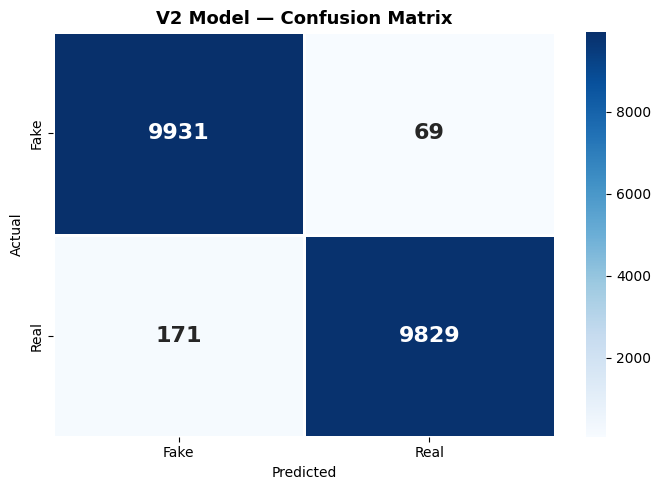

✅ V2 model saved to Drive!


In [ ]:
print("🔍 Final evaluation on test set...")
_, test_acc, test_preds, test_labels = eval_epoch(
    model, test_loader, device)

acc  = accuracy_score(test_labels,  test_preds)
prec = precision_score(test_labels, test_preds, zero_division=0)
rec  = recall_score(test_labels,    test_preds, zero_division=0)
f1   = f1_score(test_labels,        test_preds, zero_division=0)

print(f"\n{'='*50}")
print(f"  📊 V2 MODEL — FINAL TEST RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"{'='*50}")
print(classification_report(test_labels, test_preds,
                             target_names=['Fake','Real'],
                             zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'],
            linewidths=2, linecolor='white',
            annot_kws={"size":16,"weight":"bold"})
plt.title('V2 Model — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{GRAPHS_PATH}/v2_confusion_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Save final
torch.save(model.state_dict(),
           f"{MODEL_SAVE_PATH}/efficientnet_v2_final.pth")
print("✅ V2 model saved to Drive!")

In [ ]:
from PIL import Image
import torch

print("🧪 V2 Model Results:")
print("="*55)
for fname in uploaded.keys():
    img = Image.open(fname).convert('RGB')
    t   = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    fake_p = p[0][0].item()*100
    real_p = p[0][1].item()*100
    verdict = "🔴 FAKE" if fake_p >= 50 else "🟢 REAL"
    print(f"\n📷 {fname[:50]}")
    print(f"   {verdict}  |  Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")
print("="*55)

🧪 V2 Model Results:

📷 faceswap2.jpg
   🟢 REAL  |  Real: 99.1%  Fake: 0.9%


In [ ]:
from google.colab import files
from PIL import Image
import torch

print("📂 Upload more test images (3-5 face swaps, AI faces, real photos)...")
uploaded = files.upload()

print("\n🧪 V2 Model Results:")
print("="*55)
for fname in uploaded.keys():
    img = Image.open(fname).convert('RGB')
    t   = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    fake_p = p[0][0].item()*100
    real_p = p[0][1].item()*100
    verdict = "🔴 FAKE" if fake_p >= 50 else "🟢 REAL"
    print(f"\n📷 {fname[:50]}")
    print(f"   {verdict}  |  Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")
print("="*55)

📂 Upload more test images (3-5 face swaps, AI faces, real photos)...


Saving manipul.jpg to manipul.jpg
Saving videoframe_3D.png to videoframe_3D.png
Saving 3D1jpg.jpg to 3D1jpg.jpg
Saving faceswap3.jpg to faceswap3.jpg
Saving faceswap2.jpg to faceswap2 (1).jpg
Saving faceswap.jpg to faceswap.jpg

🧪 V2 Model Results:

📷 manipul.jpg
   🟢 REAL  |  Real: 100.0%  Fake: 0.0%

📷 videoframe_3D.png
   🟢 REAL  |  Real: 100.0%  Fake: 0.0%

📷 3D1jpg.jpg
   🟢 REAL  |  Real: 100.0%  Fake: 0.0%

📷 faceswap3.jpg
   🟢 REAL  |  Real: 100.0%  Fake: 0.0%

📷 faceswap2 (1).jpg
   🟢 REAL  |  Real: 99.1%  Fake: 0.9%

📷 faceswap.jpg
   🟢 REAL  |  Real: 100.0%  Fake: 0.0%


In [ ]:
from google.colab import files
from PIL import Image
import torch

print("📂 Upload more test images (3-5 face swaps, AI faces, real photos)...")
uploaded = files.upload()

print("\n🧪 V2 Model Results:")
print("="*55)
for fname in uploaded.keys():
    img = Image.open(fname).convert('RGB')
    t   = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    fake_p = p[0][0].item()*100
    real_p = p[0][1].item()*100
    verdict = "🔴 FAKE" if fake_p >= 50 else "🟢 REAL"
    print(f"\n📷 {fname[:50]}")
    print(f"   {verdict}  |  Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")
print("="*55)

📂 Upload more test images (3-5 face swaps, AI faces, real photos)...


In [ ]:
# Test on the Deepfake 60K test set specifically (face swaps)
# This tells us if the model lost face-swap detection or never had it

import os

D1_TEST_FAKE = "/content/deepfake_data/Dataset/Test/Fake"
D1_TEST_REAL = "/content/deepfake_data/Dataset/Test/Real"

# Re-download test set if deleted
if not os.path.exists(D1_TEST_FAKE):
    print("⏳ Re-downloading Deepfake 60K test set...")
    !kaggle datasets download -d manjilkarki/deepfake-and-real-images -p /content/deepfake_data/ --force
    !unzip -q /content/deepfake_data/*.zip -d /content/deepfake_data/
    !find /content -name "*.zip" -delete

deepfake_test = FolderDataset(D1_TEST_FAKE, D1_TEST_REAL, val_transforms)
deepfake_test_loader = DataLoader(deepfake_test, batch_size=32, shuffle=False)

print(f"✅ Deepfake 60K test set: {len(deepfake_test):,} images")

_, acc, preds, labels = eval_epoch(model, deepfake_test_loader, device)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(f"\n{'='*50}")
print(f"  📊 V2 MODEL ON DEEPFAKE 60K TEST SET (Face Swaps)")
print(f"{'='*50}")
print(f"  Accuracy : {accuracy_score(labels,preds)*100:.2f}%")
print(f"  Precision: {precision_score(labels,preds,zero_division=0)*100:.2f}%")
print(f"  Recall   : {recall_score(labels,preds,zero_division=0)*100:.2f}%")
print(f"  F1       : {f1_score(labels,preds,zero_division=0)*100:.2f}%")
print(classification_report(labels,preds,target_names=['Fake','Real'],zero_division=0))

⏳ Re-downloading Deepfake 60K test set...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [00:19<00:00, 94.5MB/s]

replace /content/deepfake_data/Dataset/Train/Fake/fake_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Deepfake 60K test set: 10,905 images

  📊 V2 MODEL ON DEEPFAKE 60K TEST SET (Face Swaps)
  Accuracy : 85.24%
  Precision: 95.61%
  Recall   : 73.64%
  F1       : 83.20%
              precision    recall  f1-score   support

        Fake       0.79      0.97      0.87      5492
        Real       0.96      0.74      0.83      5413

    accuracy                           0.85     10905
   macro avg       0.87      0.85      0.85     10905
weighted avg       0.87      0.85      0.85     10905



Dataset fake image size: (256, 256)
Dataset fake image mode: RGB

Your image size: (446, 632)
Your image mode: RGB


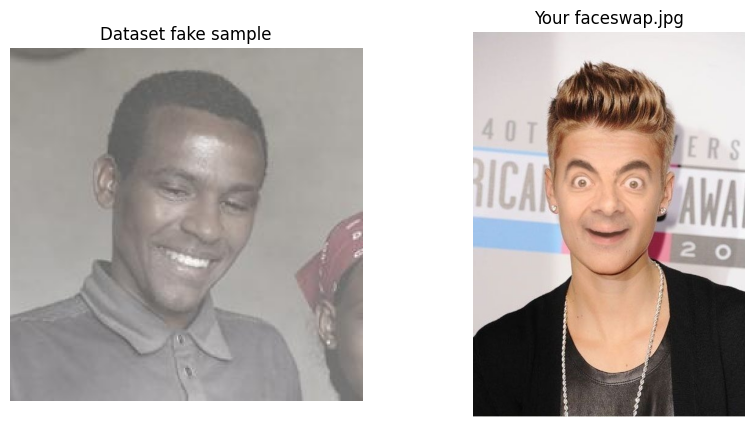

In [ ]:
# Check what's different about your images vs dataset images
import os
from PIL import Image

# Look at a sample dataset fake image
sample_dataset = os.listdir("/content/deepfake_data/Dataset/Test/Fake")[0]
ds_img = Image.open(f"/content/deepfake_data/Dataset/Test/Fake/{sample_dataset}")
print(f"Dataset fake image size: {ds_img.size}")
print(f"Dataset fake image mode: {ds_img.mode}")

# Your uploaded image
your_img = Image.open("faceswap.jpg")
print(f"\nYour image size: {your_img.size}")
print(f"Your image mode: {your_img.mode}")

# Display both side by side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(ds_img)
axes[0].set_title("Dataset fake sample")
axes[0].axis('off')
axes[1].imshow(your_img)
axes[1].set_title("Your faceswap.jpg")
axes[1].axis('off')
plt.show()

In [ ]:
from google.colab import files
from PIL import Image
import torch

print("📂 Upload a REALISTIC deepfake (not meme-style) — e.g. a frame from a face-swap deepfake video...")
uploaded = files.upload()

for fname in uploaded.keys():
    img = Image.open(fname).convert('RGB')
    t   = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    fake_p = p[0][0].item()*100
    real_p = p[0][1].item()*100
    verdict = "🔴 FAKE" if fake_p >= 50 else "🟢 REAL"
    print(f"\n📷 {fname}")
    print(f"   {verdict}  |  Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")

📂 Upload a REALISTIC deepfake (not meme-style) — e.g. a frame from a face-swap deepfake video...


Saving avatar_PNG9.png to avatar_PNG9.png

📷 avatar_PNG9.png
   🟢 REAL  |  Real: 100.0%  Fake: 0.0%


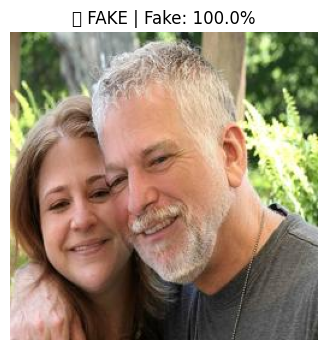

🔴 FAKE  |  Real: 0.0%  Fake: 100.0%


In [ ]:
import shutil
# Copy a sample fake image from the dataset itself
sample = "/content/deepfake_data/Dataset/Test/Fake/fake_5.jpg"
shutil.copy(sample, "/content/sample_fake.jpg")

from PIL import Image
import torch

img = Image.open("/content/sample_fake.jpg").convert('RGB')
t   = val_transforms(img).unsqueeze(0).to(device)
with torch.no_grad():
    p = torch.softmax(model(t), dim=1)
fake_p = p[0][0].item()*100
real_p = p[0][1].item()*100
verdict = "🔴 FAKE" if fake_p >= 50 else "🟢 REAL"

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"{verdict} | Fake: {fake_p:.1f}%")
plt.axis('off')
plt.show()
print(f"{verdict}  |  Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")

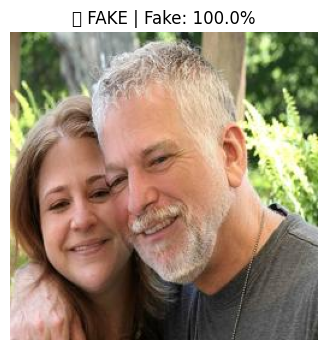

🔴 FAKE  |  Real: 0.0%  Fake: 100.0%


In [ ]:
import shutil
# Copy a sample fake image from the dataset itself
sample = "/content/deepfake_data/Dataset/Test/Fake/fake_5.jpg"
shutil.copy(sample, "/content/sample_fake.jpg")

from PIL import Image
import torch

img = Image.open("/content/sample_fake.jpg").convert('RGB')
t   = val_transforms(img).unsqueeze(0).to(device)
with torch.no_grad():
    p = torch.softmax(model(t), dim=1)
fake_p = p[0][0].item()*100
real_p = p[0][1].item()*100
verdict = "🔴 FAKE" if fake_p >= 50 else "🟢 REAL"

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"{verdict} | Fake: {fake_p:.1f}%")
plt.axis('off')
plt.show()
print(f"{verdict}  |  Real: {real_p:.1f}%  Fake: {fake_p:.1f}%")

In [ ]:
# Quick way - generate a fresh StyleGAN face right now
import urllib.request
urllib.request.urlretrieve("https://thispersondoesnotexist.com", "/content/ai_face_test.jpg")

from PIL import Image
img = Image.open("/content/ai_face_test.jpg").convert('RGB')
t = val_transforms(img).unsqueeze(0).to(device)
with torch.no_grad():
    p = torch.softmax(model(t), dim=1)
print(f"Fake: {p[0][0].item()*100:.1f}%  Real: {p[0][1].item()*100:.1f}%")
img

Backup the current best checkpoint

In [ ]:
import shutil, os

MODEL_SAVE_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model"
CURRENT_BEST = f"{MODEL_SAVE_PATH}/efficientnet_v2_best.pth"
BACKUP_PATH  = f"{MODEL_SAVE_PATH}/efficientnet_v2_best_BACKUP_DO_NOT_DELETE.pth"

if not os.path.exists(BACKUP_PATH):
    shutil.copy(CURRENT_BEST, BACKUP_PATH)
    print(f"✅ Backup created: {BACKUP_PATH}")
else:
    print(f"✅ Backup already exists — not overwritten: {BACKUP_PATH}")

print(f"\nSize check: {os.path.getsize(BACKUP_PATH)/1024**2:.1f} MB")

✅ Backup already exists — not overwritten: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v2_best_BACKUP_DO_NOT_DELETE.pth

Size check: 18.1 MB


In [ ]:
import os

# Re-auth kaggle if needed
from google.colab import files
if not os.path.exists('/root/.config/kaggle/kaggle.json'):
    print("📂 Upload kaggle.json...")
    uploaded = files.upload()
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
    os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# Check current disk space first
!df -h /content

📂 Upload kaggle.json...


Saving kaggle.json to kaggle.json
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /


In [ ]:
# IMPORTANT: check the file list inside the zip BEFORE downloading the whole thing,
# so we know the internal folder structure for selective extraction
!pip install -q kaggle
!kaggle datasets files tristanzhang32/ai-generated-images-vs-real-images | head -30

Next Page Token = CfDJ8Ih_VxHsLwdJhHStLnSaLO_71kVgXcTGSWO2MSpPsgac39vM-qV0pRUDMV3h6Emlyxhanuph6cik5GHIJEBJ2-zfm3HJAqeHgtXx15v6p_HdiQkB2lCQWm4LOjZsn_v6AX9nmDCkzGMjfQ
name                  size  creationDate                
------------------  ------  --------------------------  
test/fake/0001.jpg   94244  2024-05-23 16:06:17.936000  
test/fake/0002.jpg   35329  2024-05-23 16:06:19.569000  
test/fake/0003.jpg  309481  2024-05-23 16:05:58.948000  
test/fake/0004.jpg   35000  2024-05-23 16:06:08.348000  
test/fake/0005.jpg   90455  2024-05-23 16:06:16.364000  
test/fake/0006.jpg  112676  2024-05-23 16:06:11.466000  
test/fake/0007.jpg   60302  2024-05-23 16:06:01.774000  
test/fake/0008.jpg   56847  2024-05-23 16:06:19.913000  
test/fake/0009.jpg   36953  2024-05-23 16:06:20.025000  
test/fake/0010.jpg   75613  2024-05-23 16:06:01.898000  
test/fake/0011.jpg   16643  2024-05-23 16:06:03.410000  
test/fake/0012.jpg  670264  2024-05-23 16:06:03.620000  
test/fake/0013.jpg  628402  2024-05-2

In [ ]:
os.makedirs('/content/ai_real_small', exist_ok=True)
!kaggle datasets download -d rhythmghai/ai-vs-real-images-dataset -p /content/ai_real_small/
!unzip -q /content/ai_real_small/*.zip -d /content/ai_real_small/
!find /content/ai_real_small -name "*.zip" -delete

print("📁 rhythmghai structure (you've seen this before — confirming it's still there):")
for root, dirs, files_list in os.walk('/content/ai_real_small/'):
    imgs = [f for f in files_list if f.lower().endswith(('.jpg','.png','.jpeg'))]
    if imgs:
        print(f"  {root}: {len(imgs)} images")

Dataset URL: https://www.kaggle.com/datasets/rhythmghai/ai-vs-real-images-dataset
License(s): CC-BY-NC-SA-4.0
100% 237M/237M [00:02<00:00, 105MB/s] 

📁 rhythmghai structure (you've seen this before — confirming it's still there):
  /content/ai_real_small/Ai_generated_dataset/animals: 50 images
  /content/ai_real_small/Ai_generated_dataset/food: 50 images
  /content/ai_real_small/Ai_generated_dataset/people: 50 images
  /content/ai_real_small/Ai_generated_dataset/nature: 50 images
  /content/ai_real_small/Ai_generated_dataset/city: 50 images
  /content/ai_real_small/real_dataset/animals: 148 images
  /content/ai_real_small/real_dataset/food: 150 images
  /content/ai_real_small/real_dataset/people: 147 images
  /content/ai_real_small/real_dataset/nature: 150 images
  /content/ai_real_small/real_dataset/city: 150 images


In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
import os

api = KaggleApi()
api.authenticate()

DATASET = "tristanzhang32/ai-generated-images-vs-real-images"
TARGET_DIR = "/content/ai_subset"
N_PER_CLASS = 5000   # adjust here if you want more/fewer

os.makedirs(f"{TARGET_DIR}/train/fake", exist_ok=True)
os.makedirs(f"{TARGET_DIR}/train/real", exist_ok=True)

print(f"⏳ Downloading {N_PER_CLASS} fake + {N_PER_CLASS} real images individually...")
print("   (this takes longer than a zip but stays small on disk)")

for cls in ["fake", "real"]:
    print(f"\n📂 Class: {cls}")
    success, fail = 0, 0
    for i in range(1, N_PER_CLASS + 1):
        fname = f"{i:04d}.jpg"
        remote_path = f"train/{cls}/{fname}"
        try:
            api.dataset_download_file(
                DATASET,
                file_name=remote_path,
                path=f"{TARGET_DIR}/train/{cls}",
                force=True
            )
            success += 1
        except Exception:
            fail += 1
        if i % 500 == 0:
            print(f"   {i}/{N_PER_CLASS} attempted | success={success} fail={fail}")

    print(f"   ✅ Class {cls} done: {success} downloaded, {fail} missing/skipped")

⏳ Downloading 5000 fake + 5000 real images individually...
   (this takes longer than a zip but stays small on disk)

📂 Class: fake
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: 

KeyboardInterrupt: 

In [ ]:
# Quick test with just 20 files per class first
N_TEST = 20
for cls in ["fake", "real"]:
    for i in range(1, N_TEST + 1):
        fname = f"{i:04d}.jpg"
        try:
            api.dataset_download_file(
                DATASET, file_name=f"train/{cls}/{fname}",
                path=f"/content/ai_subset_test/{cls}", force=True)
        except Exception as e:
            print(f"  {cls}/{fname} failed: {e}")

import os
for cls in ["fake","real"]:
    p = f"/content/ai_subset_test/{cls}"
    if os.path.exists(p):
        print(f"{cls}: {len(os.listdir(p))}/{N_TEST} downloaded")

Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/trist

In [ ]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import time

api = KaggleApi()
api.authenticate()

DATASET = "tristanzhang32/ai-generated-images-vs-real-images"
TARGET_DIR = "/content/ai_subset"
N_PER_CLASS = 5000

os.makedirs(f"{TARGET_DIR}/train/fake", exist_ok=True)
os.makedirs(f"{TARGET_DIR}/train/real", exist_ok=True)

start = time.time()
print(f"⏳ Downloading {N_PER_CLASS} per class — started at {time.strftime('%H:%M:%S')}")

for cls in ["fake", "real"]:
    print(f"\n📂 Class: {cls}")
    success, fail = 0, 0
    for i in range(1, N_PER_CLASS + 1):
        fname = f"{i:04d}.jpg"
        try:
            api.dataset_download_file(
                DATASET, file_name=f"train/{cls}/{fname}",
                path=f"{TARGET_DIR}/train/{cls}", force=True)
            success += 1
        except Exception:
            fail += 1
        if i % 250 == 0:
            elapsed = time.time() - start
            rate = i / elapsed if elapsed > 0 else 0
            remaining_files = (N_PER_CLASS - i) + (N_PER_CLASS if cls=="fake" else 0)
            eta_min = remaining_files / rate / 60 if rate > 0 else 0
            print(f"   {i}/{N_PER_CLASS} | success={success} fail={fail} | "
                  f"elapsed={elapsed/60:.1f}min | ETA remaining ≈{eta_min:.1f}min")

    print(f"   ✅ {cls} complete: {success} downloaded, {fail} failed")

total_min = (time.time() - start) / 60
print(f"\n🎉 Total time: {total_min:.1f} minutes")

# Final verification
for cls in ["fake","real"]:
    p = f"{TARGET_DIR}/train/{cls}"
    print(f"{cls}: {len(os.listdir(p))} files on disk")

!df -h /content

Streaming output truncated to the last 5000 lines.
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images

In [ ]:
# Check what we actually have right now, on disk, ready to use
import os
print("What's currently usable:")
print(f"  ai_subset/train/fake: {len(os.listdir('/content/ai_subset/train/fake'))} images")
print(f"  ai_real_small/Ai_generated_dataset (all 5 categories): "
      f"{sum(len(os.listdir(f'/content/ai_real_small/Ai_generated_dataset/{c}')) for c in ['animals','food','people','nature','city'])} images")
print(f"  ai_real_small/real_dataset (all 5 categories): "
      f"{sum(len(os.listdir(f'/content/ai_real_small/real_dataset/{c}')) for c in ['animals','food','people','nature','city'])} images")

What's currently usable:


FileNotFoundError: [Errno 2] No such file or directory: '/content/ai_subset/train/fake'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch, torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for p in m.parameters(): p.requires_grad = False
    for p in m.features[5:].parameters(): p.requires_grad = True
    inf = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(inf,512), nn.ReLU(), nn.Dropout(dropout/2), nn.Linear(512,num_classes))
    return m

MODEL_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v2_best.pth"
model = build_efficientnet()
w = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(w['model_state'] if 'model_state' in w else w)
model = model.to(device).eval()

base_tfm = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),
                                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
flip_tfm = transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(p=1.0),
                                transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
crop_tfm = transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(224),
                                transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def predict_tta(pil_img):
    img = pil_img.convert('RGB')
    probs = []
    for tfm in [base_tfm, flip_tfm, crop_tfm]:
        t = tfm(img).unsqueeze(0).to(device)
        with torch.no_grad():
            p = torch.softmax(model(t), dim=1)
        probs.append(p[0].cpu().numpy())
    avg = np.mean(probs, axis=0)
    return avg[0]*100, avg[1]*100  # fake%, real%

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s] 


In [ ]:
from google.colab import files
print("Upload the same real photo from your earlier diagnostic test...")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
img = Image.open(fname)

fake_p, real_p = predict_tta(img)
print(f"TTA result: Real {real_p:.1f}%  Fake {fake_p:.1f}%")

Upload the same real photo from your earlier diagnostic test...


Saving 00023.jpg to 00023.jpg
Saving 00JEP4Z36Z.jpg to 00JEP4Z36Z.jpg
Saving image-10.png to image-10.png
Saving a949303df9fca80e03c0affe7bbad12a.jpg to a949303df9fca80e03c0affe7bbad12a.jpg
TTA result: Real 100.0%  Fake 0.0%


In [ ]:
from PIL import Image, ImageDraw

def black_out_center(pil_img, frac=0.45):
    img = pil_img.convert('RGB').copy()
    w, h = img.size
    bw, bh = int(w*frac), int(h*frac)
    x1, y1 = (w-bw)//2, (h-bh)//2
    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x1+bw, y1+bh], fill=(0,0,0))
    return img

print("="*60)
for fname in uploaded.keys():
    img = Image.open(fname).convert('RGB')
    blacked = black_out_center(img)

    fp1, rp1 = predict_tta(img)
    fp2, rp2 = predict_tta(blacked)

    print(f"\n{fname}")
    print(f"  Original      → Real {rp1:.1f}%  Fake {fp1:.1f}%")
    print(f"  Face blacked  → Real {rp2:.1f}%  Fake {fp2:.1f}%")
    print(f"  Shift: {abs(rp1-rp2):.1f} points")
print("="*60)


00023.jpg
  Original      → Real 100.0%  Fake 0.0%
  Face blacked  → Real 93.5%  Fake 6.5%
  Shift: 6.4 points

00JEP4Z36Z.jpg
  Original      → Real 0.0%  Fake 100.0%
  Face blacked  → Real 40.7%  Fake 59.3%
  Shift: 40.7 points

image-10.png
  Original      → Real 100.0%  Fake 0.0%
  Face blacked  → Real 99.4%  Fake 0.6%
  Shift: 0.6 points

a949303df9fca80e03c0affe7bbad12a.jpg
  Original      → Real 100.0%  Fake 0.0%
  Face blacked  → Real 93.3%  Fake 6.7%
  Shift: 6.7 points


In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
import os

api = KaggleApi()
api.authenticate()

DATASET = "tristanzhang32/ai-generated-images-vs-real-images"
N = 1000  # small, realistic number given time left

os.makedirs("/content/ai_subset/fake", exist_ok=True)
os.makedirs("/content/ai_subset/real", exist_ok=True)

import time
start = time.time()
for cls in ["fake", "real"]:
    ok = 0
    for i in range(1, N+1):
        try:
            api.dataset_download_file(DATASET, f"train/{cls}/{i:04d}.jpg",
                                       path=f"/content/ai_subset/{cls}", force=True)
            ok += 1
        except: pass
        if i % 100 == 0:
            print(f"{cls}: {i}/{N}, ok={ok}, {(time.time()-start)/60:.1f} min elapsed")

Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images
Dataset URL: https://www.kaggle.com/datasets/trist

In [ ]:
import os

print("Fake:", len(os.listdir("/content/ai_subset/fake")))
print("Real:", len(os.listdir("/content/ai_subset/real")))

Fake: 82
Real: 0


In [ ]:
!kaggle datasets files tristanzhang32/ai-generated-images-vs-real-images 2>/dev/null | grep "train/real" | head -5

In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SimpleDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items  # list of (path, label)
        self.transform = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        path, label = self.items[idx]
        try:
            img = Image.open(path).convert('RGB')
            return self.transform(img), torch.tensor(label, dtype=torch.long)
        except:
            return self.__getitem__((idx+1) % len(self.items))

# Collect everything available — label 0=fake, 1=real
items = []

# Your 82 downloaded fakes
fake_dir = "/content/ai_subset/fake"
if os.path.exists(fake_dir):
    items += [(os.path.join(fake_dir,f),0) for f in os.listdir(fake_dir)]

# rhythmghai AI-generated (fake) — 5 categories
rg_fake_base = "/content/ai_real_small/Ai_generated_dataset"
if os.path.exists(rg_fake_base):
    for cat in os.listdir(rg_fake_base):
        p = os.path.join(rg_fake_base, cat)
        items += [(os.path.join(p,f),0) for f in os.listdir(p)]

# rhythmghai real — 5 categories
rg_real_base = "/content/ai_real_small/real_dataset"
if os.path.exists(rg_real_base):
    for cat in os.listdir(rg_real_base):
        p = os.path.join(rg_real_base, cat)
        items += [(os.path.join(p,f),1) for f in os.listdir(p)]

random.shuffle(items)
n_fake = sum(1 for _,l in items if l==0)
n_real = sum(1 for _,l in items if l==1)
print(f"Total: {len(items)} | fake={n_fake} real={n_real}")

train_tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tfm = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

full_ds = SimpleDataset(items, train_tfm)
val_size = max(20, int(0.15*len(items)))
train_ds, val_ds = random_split(full_ds, [len(items)-val_size, val_size])
val_ds.dataset.transform = val_tfm  # use clean transform for val subset

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Total: 995 | fake=250 real=745
Train: 846 | Val: 149


In [ ]:
def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for p in m.parameters(): p.requires_grad = False
    for p in m.features[5:].parameters(): p.requires_grad = True
    inf = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(inf,512), nn.ReLU(), nn.Dropout(dropout/2), nn.Linear(512,num_classes))
    return m

MODEL_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v2_best.pth"
model = build_efficientnet()
w = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(w['model_state'] if 'model_state' in w else w)
model = model.to(device)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 6
best_val_acc = 0
best_state = None

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        correct += (out.argmax(1)==labels).sum().item()
        total += labels.size(0)
    train_acc = correct/total

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            correct += (out.argmax(1)==labels).sum().item()
            total += labels.size(0)
    val_acc = correct/total

    print(f"Epoch {epoch+1}/{EPOCHS} | Train acc {train_acc*100:.1f}% | Val acc {val_acc*100:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k:v.clone() for k,v in model.state_dict().items()}

torch.save(best_state, "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v3_finetuned.pth")
print(f"\nSaved as efficientnet_v3_finetuned.pth | Best val acc: {best_val_acc*100:.1f}%")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 107MB/s]


Epoch 1/6 | Train acc 60.9% | Val acc 72.5%
Epoch 2/6 | Train acc 70.7% | Val acc 78.5%
Epoch 3/6 | Train acc 79.1% | Val acc 81.2%
Epoch 4/6 | Train acc 83.2% | Val acc 83.9%
Epoch 5/6 | Train acc 87.9% | Val acc 87.2%
Epoch 6/6 | Train acc 90.4% | Val acc 87.2%

Saved as efficientnet_v3_finetuned.pth | Best val acc: 87.2%


In [ ]:
w = torch.load("/content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_v3_finetuned.pth", map_location=device)
model.load_state_dict(w)
model.eval()

def predict(pil_img):
    t = val_tfm(pil_img.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(t), dim=1)
    return p[0][0].item()*100, p[0][1].item()*100

from google.colab import files
print("Upload your problem images (faceswap, CGI, AI-generated, real photos)...")
uploaded = files.upload()

for fname in uploaded.keys():
    img = Image.open(fname)
    fp, rp = predict(img)
    verdict = "FAKE" if fp>=50 else "REAL"
    print(f"{fname}: {verdict} (Real {rp:.1f}% Fake {fp:.1f}%)")

Upload your problem images (faceswap, CGI, AI-generated, real photos)...


Saving 0019.jpg to 0019.jpg
Saving image-10.png to image-10.png
Saving manipul2.jpg to manipul2.jpg
Saving faceswap2.jpg to faceswap2.jpg
0019.jpg: REAL (Real 93.2% Fake 6.8%)
image-10.png: REAL (Real 91.6% Fake 8.4%)
manipul2.jpg: REAL (Real 99.8% Fake 0.2%)
faceswap2.jpg: REAL (Real 77.8% Fake 22.2%)
